In [18]:
import pandas as pd

transactions = pd.read_parquet('data/credit_card_transactions-ibm_v2.parquet')
cards = pd.read_parquet('data/sd254_cards.parquet')
users = pd.read_parquet('data/sd254_users.parquet')


In [19]:
users['User'] = users.index

data = transactions.merge(users, on='User', how='left')
cards = cards.rename(columns={'CARD INDEX': 'Card'})

all_data = data.merge(cards, on=['User', 'Card'], how='left')

all_data

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,...,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,3414527459579106770,Monterey Park,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
4,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,5817218446178736267,La Verne,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386895,1999,1,2020,2,27,22:23,$-54.00,Chip Transaction,-5162038175624867091,Merrimack,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386896,1999,1,2020,2,27,22:24,$54.00,Chip Transaction,-5162038175624867091,Merrimack,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386897,1999,1,2020,2,28,07:43,$59.15,Chip Transaction,2500998799892805156,Merrimack,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386898,1999,1,2020,2,28,20:10,$43.12,Chip Transaction,2500998799892805156,Merrimack,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No


In [42]:
print(all_data.columns)

Index(['User', 'Card', 'Year', 'Month', 'Day', 'Time', 'Amount', 'Use Chip',
       'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC',
       'Errors?', 'Is Fraud?', 'Person', 'Current Age', 'Retirement Age',
       'Birth Year', 'Birth Month', 'Gender', 'Address', 'Apartment', 'City',
       'State', 'Zipcode', 'Latitude', 'Longitude',
       'Per Capita Income - Zipcode', 'Yearly Income - Person', 'Total Debt',
       'FICO Score', 'Num Credit Cards', 'Card Brand', 'Card Type',
       'Card Number', 'Expires', 'CVV', 'Has Chip', 'Cards Issued',
       'Credit Limit', 'Acct Open Date', 'Year PIN last Changed',
       'Card on Dark Web'],
      dtype='object')


tiriam tik online transakcijas

In [20]:
mask = all_data["Merchant City"] == 'ONLINE'
data = all_data.loc[mask].copy()
data

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,...,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web
11,0,0,2002,9,5,20:41,$53.91,Online Transaction,-9092677072201095172,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
24,0,0,2002,9,9,20:02,$144.90,Online Transaction,-8338381919281017248,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
85,0,0,2002,9,30,06:21,$127.32,Online Transaction,-7421093378627544099,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
99,0,0,2002,10,6,06:14,$139.39,Online Transaction,-7421093378627544099,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
106,0,0,2002,10,9,08:16,$53.09,Online Transaction,-4956618006720593695,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386877,1999,1,2020,2,24,20:04,$55.79,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386879,1999,1,2020,2,25,07:06,$43.08,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386880,1999,1,2020,2,25,07:34,$43.76,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386884,1999,1,2020,2,26,07:43,$45.18,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No


pasiziurim kiek none  values turim transakcijose

In [21]:
missing = data.isna().sum()
print(missing)

User                                 0
Card                                 0
Year                                 0
Month                                0
Day                                  0
Time                                 0
Amount                               0
Use Chip                             0
Merchant Name                        0
Merchant City                        0
Merchant State                 2720821
Zip                            2720821
MCC                                  0
Errors?                        2659365
Is Fraud?                            0
Person                               0
Current Age                          0
Retirement Age                       0
Birth Year                           0
Birth Month                          0
Gender                               0
Address                              0
Apartment                      2020344
City                                 0
State                                0
Zipcode                  

kadangi Merchant State ir Zip neturi duomenu, o apartment neturi reiksmes, trinam situos stulpelius lauk

In [22]:
data.drop(columns = ['Merchant State', 'Zip', 'Apartment'], inplace = True)

In [ ]:
data

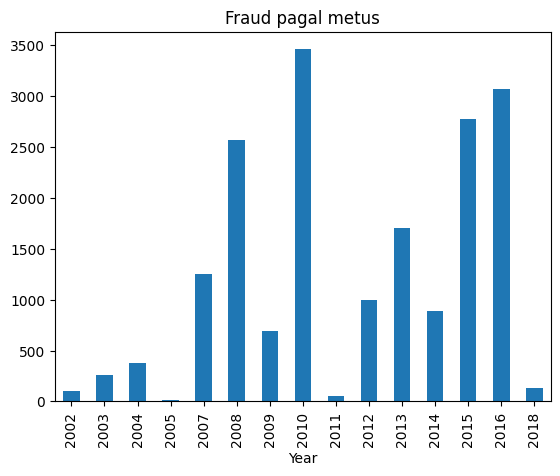

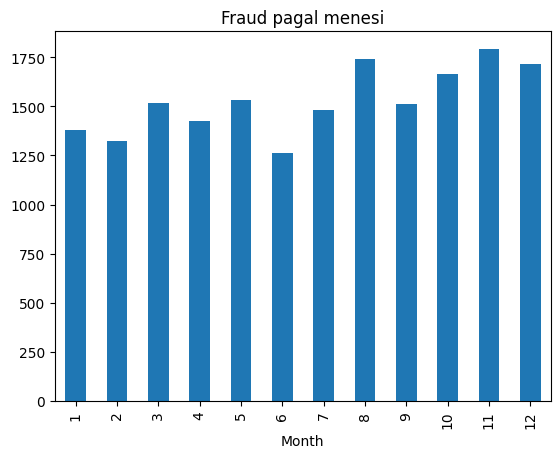

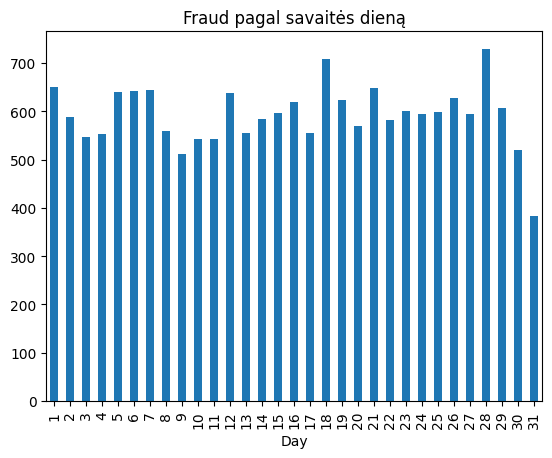

In [23]:
import matplotlib.pyplot as plt

fraud = data[data['Is Fraud?'] == 'Yes'].copy()

fraud.groupby('Year')['Is Fraud?'].count().plot(kind='bar')
plt.title('Fraud pagal metus')
plt.show()

fraud.groupby('Month')['Is Fraud?'].count().plot(kind='bar')
plt.title('Fraud pagal menesi')
plt.show()

fraud.groupby('Day')['Is Fraud?'].count().plot(kind='bar')
plt.title('Fraud pagal savaitės dieną')
plt.show()



In [ ]:
data

In [24]:
mask = data["Errors?"].isna()
data.loc[mask, "Errors?"] = False
data.loc[~mask, "Errors?"] = True
data

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,...,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web
11,0,0,2002,9,5,20:41,$53.91,Online Transaction,-9092677072201095172,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
24,0,0,2002,9,9,20:02,$144.90,Online Transaction,-8338381919281017248,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
85,0,0,2002,9,30,06:21,$127.32,Online Transaction,-7421093378627544099,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
99,0,0,2002,10,6,06:14,$139.39,Online Transaction,-7421093378627544099,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
106,0,0,2002,10,9,08:16,$53.09,Online Transaction,-4956618006720593695,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386877,1999,1,2020,2,24,20:04,$55.79,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386879,1999,1,2020,2,25,07:06,$43.08,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386880,1999,1,2020,2,25,07:34,$43.76,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386884,1999,1,2020,2,26,07:43,$45.18,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No


In [ ]:
from decimal import Decimal

data['Yearly Income - Person'] = data['Yearly Income - Person'].str.replace('$', '', regex=False).apply(Decimal)
data['Total Debt'] = data['Total Debt'].str.replace('$', '', regex=False).apply(Decimal)
data['Amount'] = data['Amount'].str.replace('$', '', regex=False).apply(Decimal)
data['Credit Limit'] = data['Credit Limit'].str.replace('$', '', regex=False).apply(Decimal)


In [33]:
data['Per Capita Income - Zipcode'] = data['Per Capita Income - Zipcode'].str.replace('$', '', regex=False).apply(Decimal)


In [28]:
data["min"] = data["Time"].apply(
    lambda x: int(x.split(":")[0]) * 60 + int(x.split(":")[1])
)

In [29]:
data.drop(columns=['Time'], inplace=True)

In [30]:
data["Expires_month"] = data["Expires"].apply(lambda x: int(x.split("/")[0]))
data["Expires_year"] = data["Expires"].apply(lambda x: int(x.split("/")[1]))

data["Acct Open Date month"] = data["Acct Open Date"].apply(lambda x: int(x.split("/")[0]))
data["Acct Open Date year"] = data["Acct Open Date"].apply(lambda x: int(x.split("/")[1]))

In [31]:
cols_to_drop = ['User', 'Card', 'Expires', 'Person', 'Acct Open Date']
data.drop(columns=cols_to_drop, inplace=True)
data

,Year,Month,Day,Amount,Use Chip,Merchant Name,Merchant City,MCC,Errors?,Is Fraud?,...,Has Chip,Cards Issued,Credit Limit,Year PIN last Changed,Card on Dark Web,min,Expires_month,Expires_year,Acct Open Date month,Acct Open Date year
11,2002,9,5,53.91,Online Transaction,-9092677072201095172,ONLINE,4900,0,0,...,YES,2,24295,2008,No,1241,12,2022,9,2002
24,2002,9,9,144.90,Online Transaction,-8338381919281017248,ONLINE,4899,0,0,...,YES,2,24295,2008,No,1202,12,2022,9,2002
85,2002,9,30,127.32,Online Transaction,-7421093378627544099,ONLINE,5311,0,0,...,YES,2,24295,2008,No,381,12,2022,9,2002
99,2002,10,6,139.39,Online Transaction,-7421093378627544099,ONLINE,5311,0,0,...,YES,2,24295,2008,No,374,12,2022,9,2002
106,2002,10,9,53.09,Online Transaction,-4956618006720593695,ONLINE,5193,0,0,...,YES,2,24295,2008,No,496,12,2022,9,2002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386877,2020,2,24,55.79,Online Transaction,-6160036380778658394,ONLINE,4121,0,0,...,YES,1,14400,2017,No,1204,12,2020,5,2017
24386879,2020,2,25,43.08,Online Transaction,-6160036380778658394,ONLINE,4121,0,0,...,YES,1,14400,2017,No,426,12,2020,5,2017
24386880,2020,2,25,43.76,Online Transaction,-6160036380778658394,ONLINE,4121,0,0,...,YES,1,14400,2017,No,454,12,2020,5,2017
24386884,2020,2,26,45.18,Online Transaction,-6160036380778658394,ONLINE,4121,0,0,...,YES,1,14400,2017,No,463,12,2020,5,2017


In [37]:
data

,Year,Month,Day,Amount,Use Chip,Merchant Name,Merchant City,MCC,Errors?,Is Fraud?,...,Has Chip,Cards Issued,Credit Limit,Year PIN last Changed,Card on Dark Web,min,Expires_month,Expires_year,Acct Open Date month,Acct Open Date year
11,2002,9,5,53.91,Online Transaction,-9092677072201095172,ONLINE,4900,0,0,...,YES,2,24295,2008,No,1241,12,2022,9,2002
24,2002,9,9,144.90,Online Transaction,-8338381919281017248,ONLINE,4899,0,0,...,YES,2,24295,2008,No,1202,12,2022,9,2002
85,2002,9,30,127.32,Online Transaction,-7421093378627544099,ONLINE,5311,0,0,...,YES,2,24295,2008,No,381,12,2022,9,2002
99,2002,10,6,139.39,Online Transaction,-7421093378627544099,ONLINE,5311,0,0,...,YES,2,24295,2008,No,374,12,2022,9,2002
106,2002,10,9,53.09,Online Transaction,-4956618006720593695,ONLINE,5193,0,0,...,YES,2,24295,2008,No,496,12,2022,9,2002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386877,2020,2,24,55.79,Online Transaction,-6160036380778658394,ONLINE,4121,0,0,...,YES,1,14400,2017,No,1204,12,2020,5,2017
24386879,2020,2,25,43.08,Online Transaction,-6160036380778658394,ONLINE,4121,0,0,...,YES,1,14400,2017,No,426,12,2020,5,2017
24386880,2020,2,25,43.76,Online Transaction,-6160036380778658394,ONLINE,4121,0,0,...,YES,1,14400,2017,No,454,12,2020,5,2017
24386884,2020,2,26,45.18,Online Transaction,-6160036380778658394,ONLINE,4121,0,0,...,YES,1,14400,2017,No,463,12,2020,5,2017


In [38]:
cols_to_drop = ['Use Chip', 'Merchant City', 'Current Age', 'Has Chip']
cols_to_encode = ['Merchant Name', 'Gender', 'Address', 'City', 'State', 'Zipcode', 'Latitude', 
                  'Longitude', 'Card Brand', 'Card Type', 'Card Number', 'CVV', 'Card on Dark Web']


In [39]:
data.drop(columns=cols_to_drop, inplace=True)

In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cols_to_encode:
    data[col] = le.fit_transform(data[col])
data

,Year,Month,Day,Amount,Merchant Name,MCC,Errors?,Is Fraud?,Retirement Age,Birth Year,...,CVV,Cards Issued,Credit Limit,Year PIN last Changed,Card on Dark Web,min,Expires_month,Expires_year,Acct Open Date month,Acct Open Date year
11,2002,9,5,53.91,0,4900,0,0,66,1966,...,621,2,24295,2008,0,1241,12,2022,9,2002
24,2002,9,9,144.90,5,4899,0,0,66,1966,...,621,2,24295,2008,0,1202,12,2022,9,2002
85,2002,9,30,127.32,15,5311,0,0,66,1966,...,621,2,24295,2008,0,381,12,2022,9,2002
99,2002,10,6,139.39,15,5311,0,0,66,1966,...,621,2,24295,2008,0,374,12,2022,9,2002
106,2002,10,9,53.09,41,5193,0,0,66,1966,...,621,2,24295,2008,0,496,12,2022,9,2002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386877,2020,2,24,55.79,27,4121,0,0,60,1998,...,120,1,14400,2017,0,1204,12,2020,5,2017
24386879,2020,2,25,43.08,27,4121,0,0,60,1998,...,120,1,14400,2017,0,426,12,2020,5,2017
24386880,2020,2,25,43.76,27,4121,0,0,60,1998,...,120,1,14400,2017,0,454,12,2020,5,2017
24386884,2020,2,26,45.18,27,4121,0,0,60,1998,...,120,1,14400,2017,0,463,12,2020,5,2017


In [41]:
data.to_parquet('data/prepared_data_good.parquet', index=False)